# Survival Analysis for Customer Churn

- [Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)
- [Dataset-Legend](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)
- [lifelines package](https://lifelines.readthedocs.io/en/latest/Survival%20Analysis%20intro.html)
- [PySurvival](https://square.github.io/pysurvival/intro.html)
- [Future Developement: Deep-Learning for Survival Analysis](https://www.kaggle.com/code/louise2001/deep-learning-for-survival-analysis/comments)

## Theory

### Concepts

- Survival analysis is a branch of statistics used to analyze the expected duration of time until one or more events happen, such as death in biological organisms and failure in mechanical systems.
- In the context of customer churn analysis, the "event" typically refers to a customer ending their relationship with a company.

- Key Concepts in Survival Analysis:
    - **Survival Function**: This estimates the probability that a customer will "survive" (not churn) up to a certain point in time.
    - **Hazard Function**: This estimates the instantaneous rate at which customers are churning at a specific time, given that they have "survived" up to that time.
    - **Censoring**: This occurs when we have incomplete information about a customer's tenure with the company (e.g., they are still active customers at the time of analysis).

### Types of Survival Models

- **Non-Parametric Models**
    - Do not assume a specific distribution for survival times.
    - Examples:
        - **Kaplan-Meier Estimator:** Estimates the survival function.
        - **Log-Rank Test:** Compares survival curves between groups.
- **Semi-Parametric Models**
    - Combine parametric and non-parametric elements.
    - Example:
        - **Cox Proportional Hazards Model:** Models the hazard function without assuming a specific baseline hazard distribution.
- **Parametric Models**
    - Assume a specific distribution for survival times.
    - Examples:
        - **Exponential Model**
        - **Weibull Model**
        - **Log-Normal Model**

## Data Preparation

In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

In [96]:
from lifelines import KaplanMeierFitter, CoxPHFitter

from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [97]:
from eda.main import get_main_eda
from eda.plot import PlotlyEDA

from survival.Survival import Survival
from survival.main import get_main_survival
from survival.plot import PlotlySurvival

from hazard.Hazard import Hazard
from hazard.main import get_main_hazard
from hazard.metrics import get_aucs_scores
from hazard.plot import PlotlyHazard

from utils import get_quick_review, get_groups_pct_survive, get_groups_pct_survives

In [160]:
import plotly.io as pio
import plotly.graph_objects as go

custom_template = go.layout.Template(
    layout=go.Layout(title=dict(font=dict(size=20, color="darkblue"), x=0.5, xanchor='center'))
)
pio.templates["my_custom"] = custom_template  # Register template
pio.templates.default = "plotly_white+my_custom"  # Set as default
px.colors.DEFAULT_PLOTLY_COLORS = px.colors.qualitative.Plotly

In [161]:
df = pd.read_csv('telco_customer_churn_clean.csv', index_col=0)
df['Churn'] = df['Churn'].astype(bool)
df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,False
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,False
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,True
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,False
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,True


In [100]:
col_cats = df.columns[df.nunique() < 10].to_list()
col_cats.remove('Churn')

## EDA

In [101]:
get_quick_review(df)

,dtype,missing values,nunique values,unique values,skewness
Gender,object,0,2,"Female, Male",NaN
SeniorCitizen,int64,0,2,NaN,1.833633
Partner,object,0,2,"Yes, No",NaN
Dependents,object,0,2,"No, Yes",NaN
Tenure,int64,0,73,NaN,0.239540
PhoneService,object,0,2,"No, Yes",NaN
MultipleLines,object,0,3,"No phone service, No, Yes",NaN
InternetService,object,0,3,"DSL, Fiber optic, No",NaN
OnlineSecurity,object,0,3,"No, Yes, No internet service",NaN
OnlineBackup,object,0,3,"Yes, No, No internet service",NaN


In [102]:
main_eda = get_main_eda(df, 'Churn', 'Tenure', col_cats)

### Churn Compositions

In [103]:
main_eda['fig_event_composition'].update_layout(height=400)

The pie chart indicates that 26.5% (1869) of our customers have churned.

### Event Composition Across Categorical Features

Question: How is the composition of events distributed among categorical variables?

In [104]:
main_eda['fig_bar_event_categorical_composition']

- Sorted by chi-square (χ²) values, the bar chart highlights how churn composition varies across each categorical feature.
- As expected, the Contract feature reflects customers’ initial subscription agreements over specific time periods.
    - Although the monthly contract type has the highest churn rate, it still accounts for the largest share of active customers compared to other contract types.
- Other features, as shown in the chart, demonstrate significant differences in churn composition based on their chi² values—except for Gender and PhoneService, which show weak or negligible associations.

### Churn Distribution Across Different Tenure

Question: How are events distributed over time?

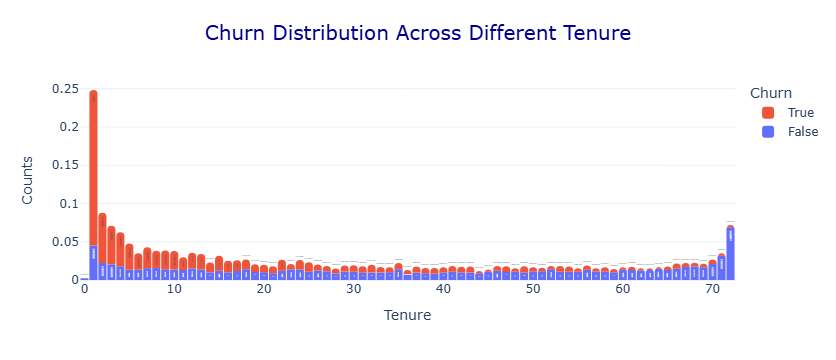

In [162]:
PlotlyEDA.plot_bar_event_time_distribution(df, 'Churn', 'Tenure', False, margin_t=80).update_traces(histnorm='probability')

- The bar chart reveals a sharp spike in churn (around 380 customers) early in the customer lifecycle. This suggests many users leave shortly after joining—possibly due to onboarding issues, unmet expectations, or a misalignment between product and customer needs.
- After this initial drop-off, churn steadily declines and stabilizes. This trend may indicate that customers who remain beyond the first few months are more likely to stay loyal, or that those who churn early differ significantly from long-term users.

### Churn Distribution Across Tenure Periods under Different Conditions

Question: How are events distributed over time under different conditions?

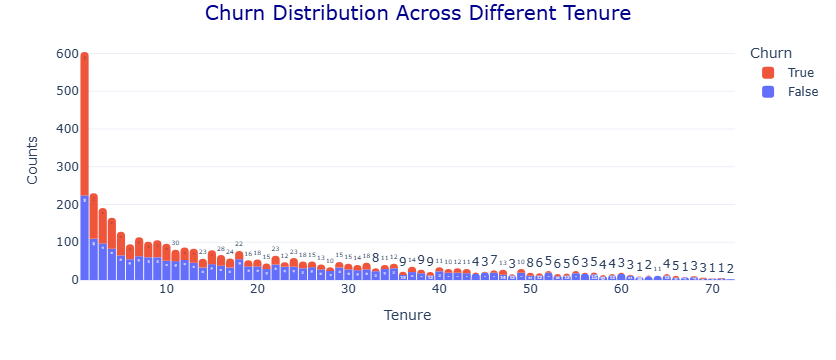

In [159]:
PlotlyEDA.plot_bar_event_time_distribution(df.query("Contract == 'Month-to-month'"), 'Churn', 'Tenure')

In [107]:
PlotlyEDA.plot_bar_event_time_distribution(df.query("Contract == 'One year'"), 'Churn', 'Tenure', yaxis_range = (0, 600))

In [108]:
PlotlyEDA.plot_bar_event_time_distribution(df.query("Contract == 'Two year'"), 'Churn', 'Tenure', yaxis_range = (0, 600))

- The bar charts clearly illustrate how churn composition varies across customer tenure for each contract type.
- For Month-to-month contracts, the majority of churn occurs within the first year—particularly in the first month. Churn then drops sharply until month six, followed by a steady decline. Very few customers remain active beyond five years.
- The One-year contract displays a relatively uniform distribution of churn across tenure, suggesting consistent retention dynamics throughout the contract period.
- The Two-year contract displays a higher proportion of long-term customers, many of whom have remained active for over five years. This suggests strong loyalty among existing subscribers. However, the lower presence of newer users on this contract type may indicate a shift in preference toward more flexible, short-term plans—potentially challenging future retention

### Feature Assosiation with Event (chi2 test)

Question: What are the associations between each category and the event under the chi-squared test?

In [109]:
main_eda['chi2_stats']

,chi2,dof,pval,cramer
Contract,1184.5966,2.0,0.0000,0.4101
OnlineSecurity,849.9990,2.0,0.0000,0.3474
TechSupport,828.1971,2.0,0.0000,0.3429
InternetService,732.3096,2.0,0.0000,0.3225
PaymentMethod,648.1423,3.0,0.0000,0.3034
OnlineBackup,601.8128,2.0,0.0000,0.2923
DeviceProtection,558.4194,2.0,0.0000,0.2816
StreamingMovies,375.6615,2.0,0.0000,0.2310
StreamingTV,374.2039,2.0,0.0000,0.2305
PaperlessBilling,258.2776,1.0,0.0000,0.1915


- As shown in the table, Gender and PhoneService have high p-values, indicating no significant association with churn; therefore, we exclude them from the hazard modeling process.
- The remaining categorical features exhibit statistically significant p-values, supporting their inclusion in the model.

### Pearson Correlation Coefficient Between Churn and each Feature

Question: How does each feature correlate with the likelihood of the event occurring?

In [110]:
main_eda['fig_bar_corr']

Question: Do different values within each variable show varying associations with the event occurrence?

In [111]:
main_eda['fig_bar_corr_grouped'].update_layout(height=600)

- The bar chart shows that MonthlyCharges has a mild positive correlation (~0.20) with churn. This likely reflects pricing differences, as short-term contracts—linked to higher churn—often come with higher monthly costs.
- TotalCharges shows a negative correlation with churn, as higher spending typically reflects longer tenure—meaning these customers are still active and have not churned.
- Together, MonthlyCharges, TotalCharges, and Contract capture overlapping aspects of tenure and pricing. While not a direct case of data leakage, their interdependence warrants caution—especially with multicollinearity in modeling.

## Survival Function Estimation

What is the estimated probability that an individual survives beyond a certain time?

### Concepts

<b>Definition</b>: <br>
The survival function 𝑆(𝑡) gives the probability that an individual will survive (or not experience the event of interest) beyond time 𝑡: <br>
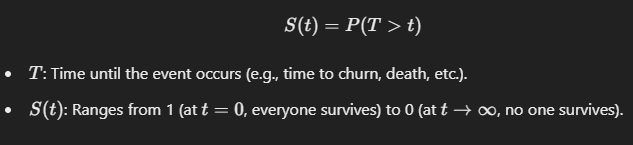
- Questions It Answers:
    1. What is the probability of surviving beyond a specific time 𝑡?
         - Example: What is the probability that a customer remains active after 6 months?
    2. How does survival probability change over time?
        - The survival curve provides a complete picture of survival rates over time.
- Purpose:
    1. The survival function focuses on absolute probabilities of survival over time.
    2. It gives time-dependent insights, showing how the risk of experiencing the event accumulates as time progresses.


### Survival Function Curve

Question: What does the Kaplan-Meier survival curve look like across different time periods?

In [112]:
main_survival = get_main_survival(df, 'Churn', 'Tenure', True, col_cats)

In [113]:
main_survival['base']['survival_curve']

- The most significant drop in the curve occurs within the first month after customers engage, with a 5% decline. This suggests that many users are simply testing the service.
- After the first month, the curve continues to decline at a consistent pace each month, indicating a steady rate of churn.
- After 5 years (60 months of tenure), the survival function remains above 65%, indicating long-term retention stability.

### Survival Curves Across the Unique Values of each Categorical Feature

Question: How do survival curves differ across categories within each categorical feature?

In [115]:
def fig_selector(fig, groups):        
    fig.update_traces(visible=False, showlegend=False)
    for trace in fig.data:
        if trace['legendgroup'] in groups:
            trace.update(visible=True, showlegend=True)

    return fig

In [116]:
def get_selected_surv(df, cols, idx):
    return df[df.columns[df.columns.map(lambda x: x.split(' | ')[0] in cols)]].loc[idx]

In [117]:
survival_functtions = main_survival['group']['survival_functions']

In [118]:
get_selected_surv(survival_functtions, ['Contract'], [0, 1, 12, 24, 36, 48, 60, 72]).diff()

Var | Value,Contract | Month-to-month,Contract | One year,Contract | Two year
Tenure,,,
0.0,NaN,NaN,NaN
1.0,-0.098065,0.000000,0.000000
12.0,-0.198839,-0.009192,0.000000
24.0,-0.117181,-0.012536,0.000000
36.0,-0.094812,-0.018965,-0.001324
48.0,-0.093840,-0.042760,-0.002957
60.0,-0.100106,-0.084721,-0.009519
72.0,-0.168206,-0.263680,-0.050461


In [119]:
survival_curves = main_survival['group']['survival_curves']

### Socio-Demographic Features

In [120]:
SOCIO_FEATURES = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig_selector(survival_curves, SOCIO_FEATURES).update_layout(height=500)

In [121]:
get_groups_pct_survive(df, 'Churn', 1, ['Partner', 'SeniorCitizen', 'Dependents'])

,Partner,SeniorCitizen,Dependents,Churn,size,n,PaSeDe -> Churn=1 (%)
1,No,0,No,True,847,2719,31.15
3,No,0,Yes,True,75,353,21.25
5,No,1,No,True,276,561,49.20
7,No,1,Yes,True,2,8,25.00
9,Yes,0,No,True,242,1163,20.81
11,Yes,0,Yes,True,229,1666,13.75
13,Yes,1,No,True,178,490,36.33
15,Yes,1,Yes,True,20,83,24.10


- The Partner feature shows a significant difference in survival probabilities.
- Among all socio-demographic features, only Gender did not reach statistical significance.
- Customers who have a partner, are not senior citizens, and live with dependents have the lowest churn rate, at only 13.75%.
- Customers who have no partner, are senior citizens, and have no dependents exhibit the highest churn rate, approaching 50%.

### Product/Services Features

In [122]:
PROD_FEATURES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                 'StreamingMovies']
fig_selector(survival_curves, PROD_FEATURES)

In [123]:
get_groups_pct_survive(df, 'Churn', 1, ['InternetService', 'OnlineBackup', 'OnlineSecurity'])

,InternetService,OnlineBackup,OnlineSecurity,Churn,size,n,InOnOn -> Churn=1 (%)
1,DSL,No,No,True,274,792,34.60
3,DSL,No,Yes,True,69,543,12.71
5,DSL,Yes,No,True,73,449,16.26
7,DSL,Yes,Yes,True,43,637,6.75
9,Fiber optic,No,No,True,783,1403,55.81
11,Fiber optic,No,Yes,True,107,350,30.57
13,Fiber optic,Yes,No,True,331,854,38.76
15,Fiber optic,Yes,Yes,True,76,489,15.54
17,No,No internet service,No internet service,True,113,1526,7.40


- All product and service features, except PhoneService, show a significant p-value.
- Customers who subscribe to DSL internet service along with both OnlineBackup and OnlineSecurity have the lowest churn rate at 6.75%. However, when they do not subscribe to these services (OnlineBackup and OnlineSecurity), the churn rate increases significantly to 34.6%.
- Customers without internet service have a churn rate of 7.4%.
- Customers who subscribe only to Fiber Optic internet service, without OnlineBackup and OnlineSecurity, have the highest churn rate at 55.8%.

### Payment Features

In [124]:
PAYMENT_FEATURES = ['Contract', 'PaperlessBilling', 'PaymentMethod']
fig_selector(survival_curves, PAYMENT_FEATURES)

In [125]:
get_groups_pct_survives(df, 'Churn', 1, ['Contract', 'PaymentMethod', 'PaperlessBilling'])

,Contract,PaymentMethod,PaperlessBilling,Churn,size,n,Co -> Churn=1 (%),CoPa -> Churn=1 (%),CoPaPa -> Churn=1 (%)
0,Month-to-month,Bank transfer (automatic),No,True,55,206,42.71,34.13,26.70
1,Month-to-month,Bank transfer (automatic),Yes,True,146,383,42.71,34.13,38.12
2,Month-to-month,Credit card (automatic),No,True,45,161,42.71,32.78,27.95
3,Month-to-month,Credit card (automatic),Yes,True,133,382,42.71,32.78,34.82
4,Month-to-month,Electronic check,No,True,188,453,42.71,53.73,41.50
5,Month-to-month,Electronic check,Yes,True,806,1397,42.71,53.73,57.70
6,Month-to-month,Mailed check,No,True,118,469,42.71,31.58,25.16
7,Month-to-month,Mailed check,Yes,True,164,424,42.71,31.58,38.68
8,One year,Bank transfer (automatic),No,True,11,171,11.27,9.72,6.43
9,One year,Bank transfer (automatic),Yes,True,27,220,11.27,9.72,12.27


- Customers with a two-year contract generally have a churn rate of only 2.83%. Among them, those who use Mailed Check as their payment method and opt for manual (non-paperless) billing have the lowest churn rate at just 0.37%. Conversely, the highest churn rate within this group is 9.82% for customers who use Electronic Check with paperless billing.
- Customers who use Electronic Check as their payment method with paperless billing experience a churn rate that is twice as high across different contract types.
- 42% of customers with a monthly contract have churned, with the highest churn rate at 57.7% for those who use Electronic Check with paperless billing.

## Hazard Modeling

### Concepts

- The Cox PH model estimates the **relative risk** (or hazard) of experiencing the event at time t, based on covariates.
- Purpose:
    1. The Cox model focuses on the relative effects of covariates on the hazard (risk) of the event.
    2. It provides comparative risk insights but does not directly estimate survival probabilities or the absolute baseline hazard.
-  The hazard function h(t) is expressed as: <br>
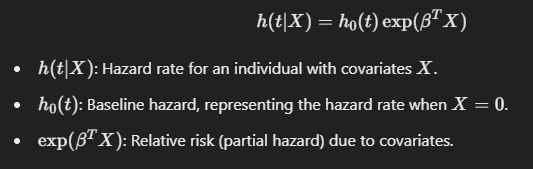
<br><b>Questions It Answers:</b>
1. How do specific factors (covariates) affect the risk of experiencing the event?
    - Example: How does age or usage frequency influence the risk of customer churn?
2. What is the relative risk between groups?
    - Example: How much more likely are high-usage customers to churn compared to low-usage customers?

### Data Preprocessing 

#### Drop Insignificant Features

In [126]:
logrank_tests = main_survival['group']['report']['logrank_tests']
logrank_tests.index[logrank_tests['p'] > 0.01]

Index(['Gender', 'PhoneService'], dtype='object', name='Variable')

In [127]:
df_clean = df.drop(columns=['Gender', 'PhoneService']).copy()

#### Split Dataset

In [128]:
y = Surv.from_dataframe('Churn', 'Tenure', df_clean)
X = df_clean.drop(columns=['Churn', 'Tenure'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y['Churn'])
df_train, df_test = df_clean.loc[X_train.index, :], df_clean.loc[X_test.index, :]

### Ranked Target Mean Encoding

In [129]:
from hazard.preprocessing import target_mean_encoder

In [130]:
col_groups = df_clean.select_dtypes(exclude='number').columns
col_groups = col_groups.drop(['Churn'])

In [131]:
labels_decoder = {}
labels_encoder = {}
for col_group in col_groups:
    encoder, decoder, mean = target_mean_encoder(df_train, 'Churn', col_group, use_rank=True)
    
    unique_val_test = X_test[col_group].unique()
    unseen_val = [col for col in unique_val_test if col not in encoder]            
    
    if len(unseen_val) > 0:
        new_map = {col:mean-(0.01*i) for i, col in enumerate(unseen_val)}
        encoder.update(new_map)
        decoder = {v:k for k,v in encoder.items()}
                                                    
    df_train[col_group] = df_train[col_group].map(encoder)
    df_test[col_group] = df_test[col_group].map(encoder)
    X_train[col_group] = X_train[col_group].map(encoder)
    X_test[col_group] = X_test[col_group].map(encoder)

    df_clean[col_group] = df_clean[col_group].map(encoder)

    labels_decoder[col_group] = decoder
    labels_encoder[col_group] = encoder

### Feature Engineering

#### Transform Numeric into Quantile

In [132]:
for col_num in ['MonthlyCharges', 'TotalCharges']:
    # new_col_num = col_num
    new_col_num = f"{col_num} (Q)"
    df_train[new_col_num], bins = pd.qcut(df_train[col_num], 4, duplicates='drop', retbins=True, labels=False)
    X_train[new_col_num] = pd.cut(X_train[col_num], bins=bins, labels=False, include_lowest=True)
    
    bins[0] = df[col_num].min()
    bins[-1] = df[col_num].max()
    
    df_test[new_col_num] = pd.cut(df_test[col_num], bins=bins, labels=False, include_lowest=True)    
    X_test[new_col_num] = pd.cut(X_test[col_num], bins=bins, labels=False, include_lowest=True)
    
    df_clean[new_col_num] = pd.cut(df_clean[col_num], bins=bins, labels=False, include_lowest=True)

#### Add Model Prediction (Optional: increase 2% scores)

In [ ]:
import xgboost as xgb

In [ ]:
model = xgb.XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train['Churn'])
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test['Churn'], y_pred):.4f}")

df_clean['xgbc_proba'] = model.predict_proba(df_clean.drop(['Churn', 'Tenure'], axis=1))[:, 1]
df_train['xgbc_proba'] = model.predict_proba(X_train)[:, 1]
df_test['xgbc_proba'] = model.predict_proba(X_test)[:, 1]
X_train['xgbc_proba'] = df_train['xgbc_proba'].copy()
X_test['xgbc_proba'] = df_test['xgbc_proba'].copy()

### Model Fitting

In [133]:
cph_base = CoxPHFitter()
cph_base.fit(df_train, 'Tenure', 'Churn')

<lifelines.CoxPHFitter: fitted with 4930 total observations, 3622 right-censored observations>

### Model Evaluation

Question: How accurately does the CoxPH model predict time to event, as evaluated by concordance index or time-dependent AUC?

In [134]:
risk_scores_train = cph_base.predict_partial_hazard(df_train)
risk_scores_test = cph_base.predict_partial_hazard(df_test)

print('C-Index-Train: ', cph_base.concordance_index_)
print('C-Index-Test: ', cph_base.score(df_test, 'concordance_index'))
print('C-IndexC-Train:', concordance_index_censored(df_train['Churn'], df_train['Tenure'], risk_scores_train)[0])
print('C-IndexC-Test:', concordance_index_censored(df_test['Churn'], df_test['Tenure'], risk_scores_test)[0])
print('AUCs-Train:', get_aucs_scores(cph_base, y_train, y_train, X_train, 'Tenure')[1])
print('AUCs-Test:', get_aucs_scores(cph_base, y_train, y_test, X_test, 'Tenure')[1])

C-Index-Train:  0.9463814742551926
C-Index-Test:  0.9413676866038766
C-IndexC-Train: 0.9463814742551926
C-IndexC-Test: 0.9413676866038766
AUCs-Train: 0.9729626572932354
AUCs-Test: 0.9710585785445149


The survival model exhibits strong predictive performance with minimal overfitting, as shown by the following metrics:
- Concordance Index (C-Index) & C-IndexC (Censored):
    - Train: 0.9463
    - Test: 0.9413
    - High agreement between predicted and actual survival rankings, including censored cases.
- Cumulative Dynamic AUC:
    - Train: 0.9729
    - Test: 0.9710
    - Excellent discriminatory ability in time-dependent survival probability estimation.
- The close alignment between train and test results highlights good generalization and model robustness for survival prediction.

In [135]:
# Question: How reliable is each covariate based on its z-score, p-value, and -log2(p) score?
cph_base.summary.sort_values('coef', ascending=False).round(3)

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
Contract,1.489,4.434,0.091,1.310,1.669,3.706,5.305,0.0,16.284,0.000,195.640
OnlineSecurity,0.305,1.356,0.073,0.161,0.448,1.174,1.566,0.0,4.152,0.000,14.886
InternetService,0.263,1.301,0.155,-0.041,0.566,0.960,1.762,0.0,1.698,0.090,3.481
OnlineBackup,0.232,1.261,0.061,0.112,0.352,1.118,1.422,0.0,3.779,0.000,12.635
TechSupport,0.222,1.249,0.075,0.076,0.369,1.078,1.446,0.0,2.970,0.003,8.391
PaperlessBilling,0.221,1.248,0.068,0.087,0.356,1.091,1.427,0.0,3.236,0.001,9.689
Dependents,0.189,1.208,0.084,0.025,0.353,1.026,1.423,0.0,2.264,0.024,5.406
Partner,0.142,1.153,0.066,0.013,0.271,1.013,1.311,0.0,2.159,0.031,5.017
PaymentMethod,0.132,1.141,0.028,0.078,0.186,1.081,1.205,0.0,4.784,0.000,19.152


- Since a churn event is represented by a value of True (1), a positive coefficient indicates a higher risk of churn.

In [136]:
insignificant_p_cols = cph_base.summary.index[cph_base.summary['p'] > 0.05]
insignificant_p_cols

Index(['SeniorCitizen', 'MultipleLines', 'InternetService', 'DeviceProtection',
       'StreamingTV', 'StreamingMovies', 'MonthlyCharges (Q)'],
      dtype='object', name='covariate')

In [137]:
insignificant_logp_cols = cph_base.summary.index[cph_base.summary['-log2(p)'] < 10]
insignificant_logp_cols

Index(['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
       'InternetService', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges (Q)'],
      dtype='object', name='covariate')

### Model Comparison

In [138]:
cph_report = Hazard.get_cph_lifelines(df_clean, 'Churn', 'Tenure', 0.3)
cphsk_report = Hazard.get_cph_sksurv(df_clean, 'Churn', 'Tenure', 0.3)
cph2_report = Hazard.get_cph_lifelines(df_clean.drop(insignificant_p_cols, axis=1), 'Churn', 'Tenure', 0.3, 'cph2')
cphsk2_report = Hazard.get_cph_sksurv(df_clean.drop(insignificant_p_cols, axis=1), 'Churn', 'Tenure', 0.3, 'cphsk2')
cph3_report = Hazard.get_cph_lifelines(df_clean.drop(insignificant_logp_cols, axis=1), 'Churn', 'Tenure', 0.3, 'cph3')
cphsk3_report = Hazard.get_cph_sksurv(df_clean.drop(insignificant_logp_cols, axis=1), 'Churn', 'Tenure', 0.3, 'cphsk3')

In [139]:
pd.concat([
    cph_report['scores'], cph2_report['scores'], cph3_report['scores'], 
    cphsk_report['scores'], cphsk2_report['scores'], cphsk3_report['scores']
], axis=1).style.highlight_max(axis=1, color='teal').highlight_min(axis=1, color='tomato')

,CoxPHFitter,cph2,cph3,CoxPHSurvivalAnalysis,cphsk2,cphsk3
Concordance Index Train,0.946381,0.946461,0.945958,0.946484,0.946569,0.946071
Concordance Index Test,0.941368,0.941564,0.941654,0.941507,0.941666,0.941747
Concordance Index Censored Train,0.946381,0.946461,0.945958,0.946484,0.946569,0.946071
Concordance Index Censored Test,0.941368,0.941564,0.941654,0.941507,0.941666,0.941747
AUCs Train,0.972963,0.972969,0.972944,0.973032,0.973077,0.973070
AUCs Test,0.971059,0.971157,0.971216,0.971208,0.971199,0.971236


- CoxPHFitter, CoxPHSurvivalAnalysis: Include all columns.
- cph2, cphsk2: Exclude columns with an insignificant p-value (> 0.05).
- cph3, cphsk3: Exclude columns with an insignificant logp value (< 10).
- As shown in the comparison table above, the differences between the models and their combined feature sets are not significant. Therefore, we can select any of them, or strategically opt for the option with the least number of predictors to reduce computational load.

### Model Selection

In [140]:
effective_features = ['Churn', 'Tenure', 'Contract', 'InternetService', 'TotalCharges', 'TotalCharges (Q)']

In [141]:
df_effective = df_clean[effective_features]

In [142]:
cph_report_e = Hazard.get_cph_lifelines(df_effective, 'Churn', 'Tenure', 0.3)
cphsk_report_e = Hazard.get_cph_sksurv(df_effective, 'Churn', 'Tenure', 0.3)

After several experiments to identify the optimal combination of predictor sets, we found that Contract, InternetService, TotalCharges, and TotalCharges (Q) form the most effective combination, as shown in the table below.

In [143]:
pd.concat([cph_report_e['scores'], cphsk_report_e['scores']], axis=1).style.highlight_max(axis=1, color='teal')

,CoxPHFitter,CoxPHSurvivalAnalysis
Concordance Index Train,0.956506,0.956672
Concordance Index Test,0.952588,0.952735
Concordance Index Censored Train,0.956506,0.956672
Concordance Index Censored Test,0.952588,0.952735
AUCs Train,0.978796,0.978891
AUCs Test,0.977329,0.977417


### Model Visualization

In [144]:
cph = cph_report_e
cph['obj'].df = cph['df']['test']

cphsk = cphsk_report_e
cphsk['obj'].df = cphsk['df']['test']

#### Plot Features Coefficient

Question: What are the coefficient values for each covariate in the Cox Proportional Hazards model?

In [145]:
PlotlyHazard.plot_features_coefficient(cphsk['obj'], showlegend=False)

In [146]:
PlotlyHazard.plot_features_coefficient_ci(cph['obj'], showlegend=False)

- The floating bar chart above illustrates each covariate’s coefficient alongside its confidence interval.
- Among all variables, TotalCharges (Q), Contract, and InternetService emerge as the strongest predictors of churn risk.
- As expected, TotalCharges (Q) has a negative coefficient—indicating that customers who have spent more over time are typically long-term users and less likely to churn.
- Since TotalCharges is already captured by the quantized version (TotalCharges (Q)), its coefficient shrinks close to zero.
- With ranked target mean encoding applied, the Contract type most associated with churn is represented by rank 2—corresponding to the Month-to-month plan—which substantially increases churn risk.
- For InternetService, customers with Fiber optic (also ranked 2) exhibit a strong positive coefficient (~2), suggesting a higher likelihood of churn. In contrast, customers with "No" internet service (rank 0) are less likely to churn.

#### Plot AUCs Line

Question: How accurately does the CoxPH model predict time to event, as evaluated by concordance index or time-dependent AUC?

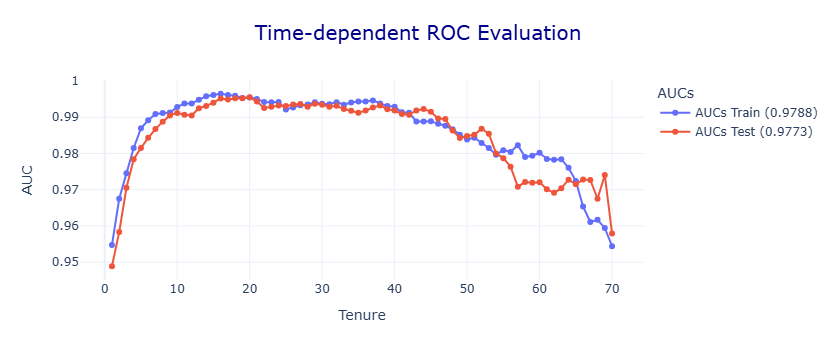

In [153]:
PlotlyHazard.plot_dynamic_auc_line(cph['times_auc'])

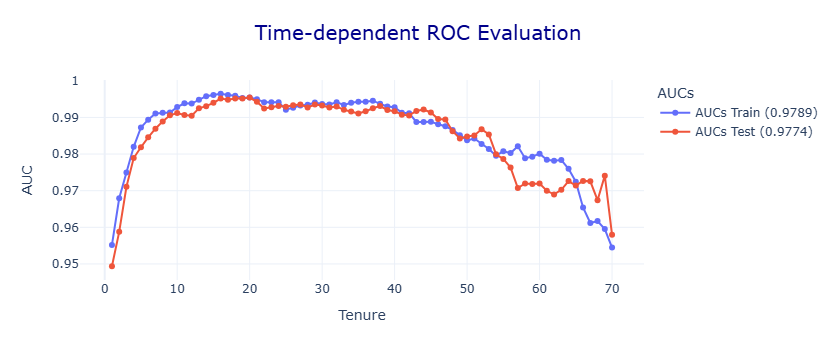

In [154]:
PlotlyHazard.plot_dynamic_auc_line(cphsk['times_auc'])

- High initial AUCs: Both training and testing curves start high (~0.95), indicating strong early predictive performance.
- Stable Mid-range Performance (Tenure 5–40): The AUC remains very high (around 0.99), suggesting the model is performing exceptionally well in this middle range of time.
- Degradation Over Time (Post-40 Tenure): AUC values for both train and test begin to decline gradually, with a noticeable drop after around tenure 60. This could be due to fewer samples available at longer tenures, or that model generalization weakens over time.
- Train vs Test Consistency: The test curve closely follows the train curve, indicating good generalization and low overfitting.

#### Plot Covariate Partial Effects

Question: How do within-group differences in covariate values affect the shape of the survival function?

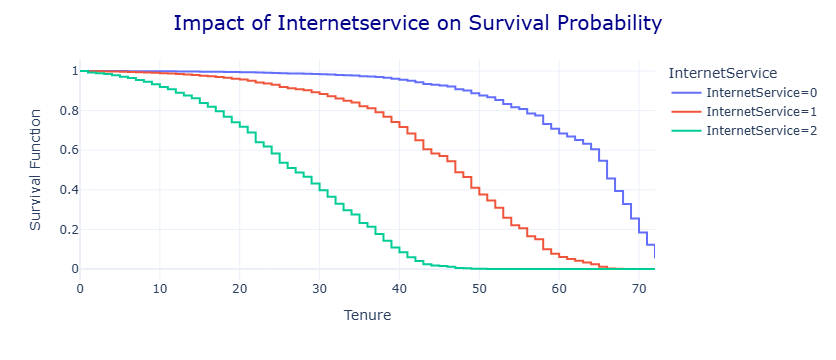

In [164]:
PlotlyHazard.plot_partial_effects_on_outcome(cph['obj'], 'InternetService')

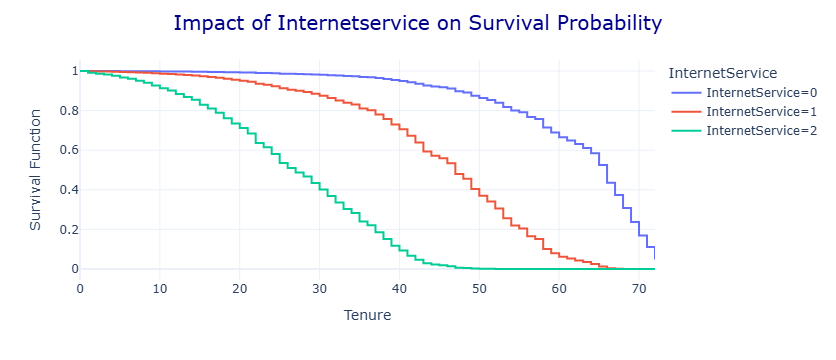

In [165]:
PlotlyHazard.plot_partial_effects_on_outcome(cphsk['obj'], 'InternetService')

- As shown in the chart above, survival curves differ significantly across InternetService types.
- The survival curve for Fiber optic declines steadily from the start of the tenure period, falling below 50% after 26 months.
- After three years, the survival rate for Fiber optic drops to 21%, whereas DSL and No InternetService retain higher rates of 81% and 97%, respectively.
- By year four, the survival rate for Fiber optic falls to 0%, DSL declines sharply to 46.5%, while No InternetService still maintains a rate above 90%.
- By year five, only the No InternetService category continues to retain a substantial portion of customers, with a survival rate of 68.4%.

#### Plot Survival Function Curve Based on Hazard Quartiles

Question: How well does the model stratify observations into risk groups (e.g., quartiles based on predicted hazard)?

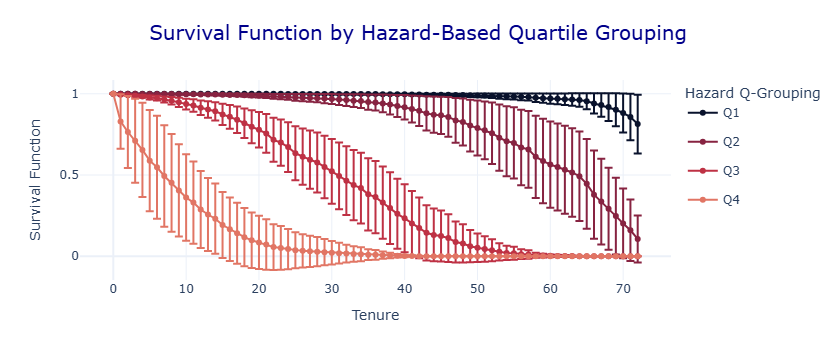

In [149]:
PlotlyHazard.plot_quartile_hazard_mean_survival(cph['obj'])

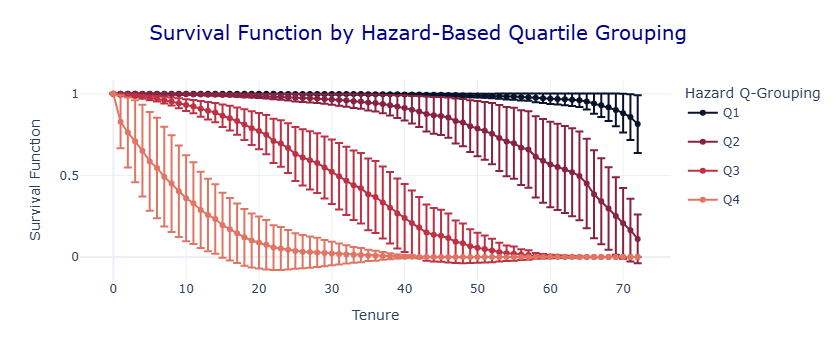

In [150]:
PlotlyHazard.plot_quartile_hazard_mean_survival(cphsk['obj'])

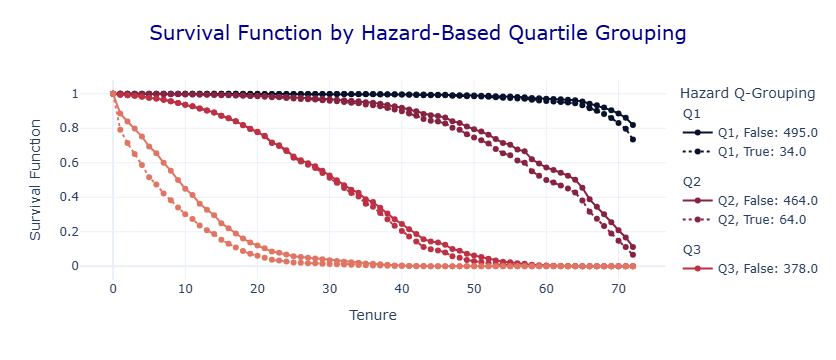

In [151]:
PlotlyHazard.plot_quartile_hazard_mean_survival_by_event(cph['obj'])

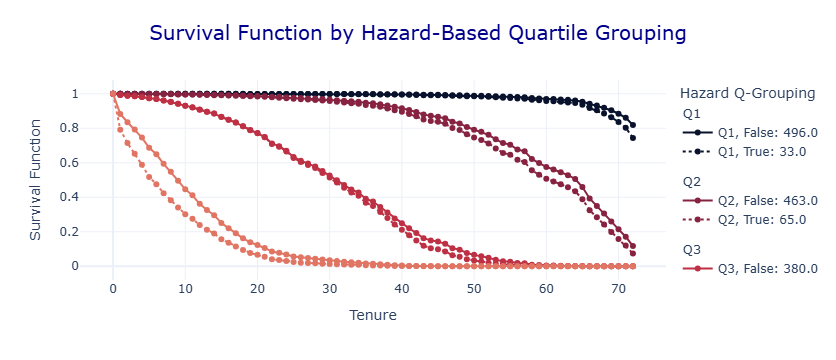

In [152]:
PlotlyHazard.plot_quartile_hazard_mean_survival_by_event(cphsk['obj'])

- The survival curves clearly demonstrate how well the hazard model separates customers based on quartile-based risk levels.
- Each curve successfully distinguishes churned from non-churned customers, with the churned group appearing lower and the non-churned group higher, as expected.

### Model Prediction

In [155]:
survival_prediction = Hazard.get_survival_prediction(cph['obj'], cph['obj'].df.iloc[:10])

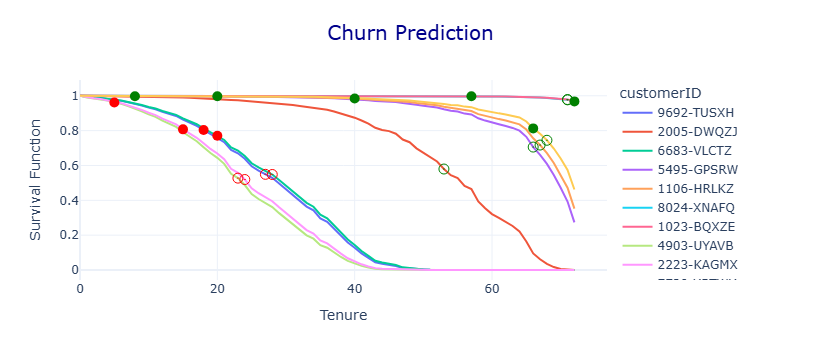

In [156]:
PlotlyHazard.plot_survival_prediction(cph['obj'], cph['obj'].df.iloc[:10], survival_prediction)

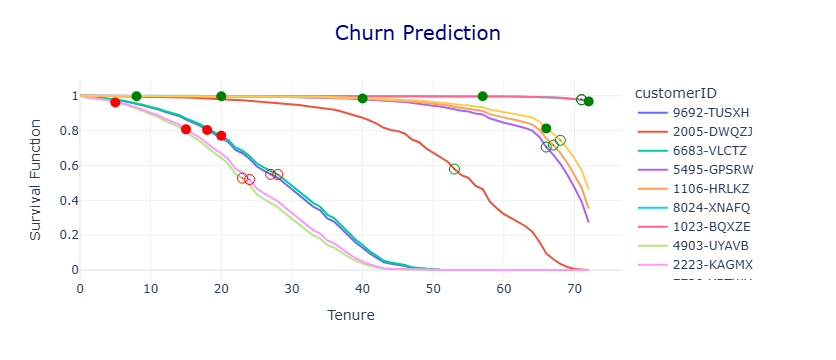

In [157]:
PlotlyHazard.plot_survival_prediction(cph['obj'], cph['obj'].df.iloc[:10])